Link to github: https://github.com/minii-max/DSA4262.git

In [1]:
import pandas as pd

In [2]:
# Load dataset
df = pd.read_csv('dreaddit-train.csv')
df_test = pd.read_csv('dreaddit-test.csv')

# Exploratory Data Analysis (EDA)

##Check for Missing Values

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(df.isnull().sum())
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

# no missing values

,0
subreddit,0
post_id,0
sentence_range,0
text,0
id,0
label,0
confidence,0
social_timestamp,0
social_karma,0
syntax_ari,0


## Check for class imbalance

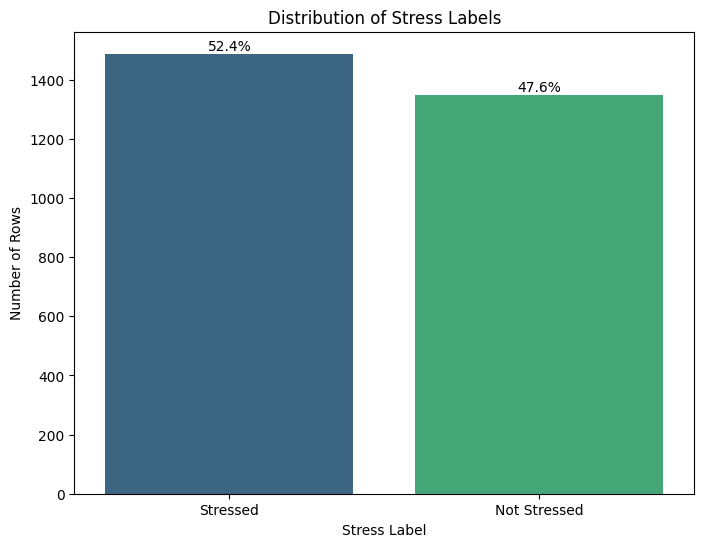

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each label
label_counts = df['label'].value_counts().reset_index()
label_counts.columns = ['label', 'count']

# Map numerical labels to descriptive strings for better readability in the plot
label_counts['label_description'] = label_counts['label'].map({0: 'Not Stressed', 1: 'Stressed'})

# Calculate percentages
total_count = label_counts['count'].sum()
label_counts['percentage'] = (label_counts['count'] / total_count) * 100

plt.figure(figsize=(8, 6))
sns.barplot(x='label_description', y='count', hue='label_description', data=label_counts, palette='viridis', legend=False)
plt.title('Distribution of Stress Labels')
plt.xlabel('Stress Label')
plt.ylabel('Number of Rows')
plt.xticks(rotation=0)

# Add percentages on top of the bars
for index, row in label_counts.iterrows():
    plt.text(index, row['count'], f'{row['percentage']:.1f}%', color='black', ha='center', va='bottom')

plt.show()

We check for class imbalance. The distribution of rows labelled stressed and not stressed seems to be fairly equal.

## Distribution of posts labelled 'Stress' across subreddits

<Figure size 1500x800 with 0 Axes>

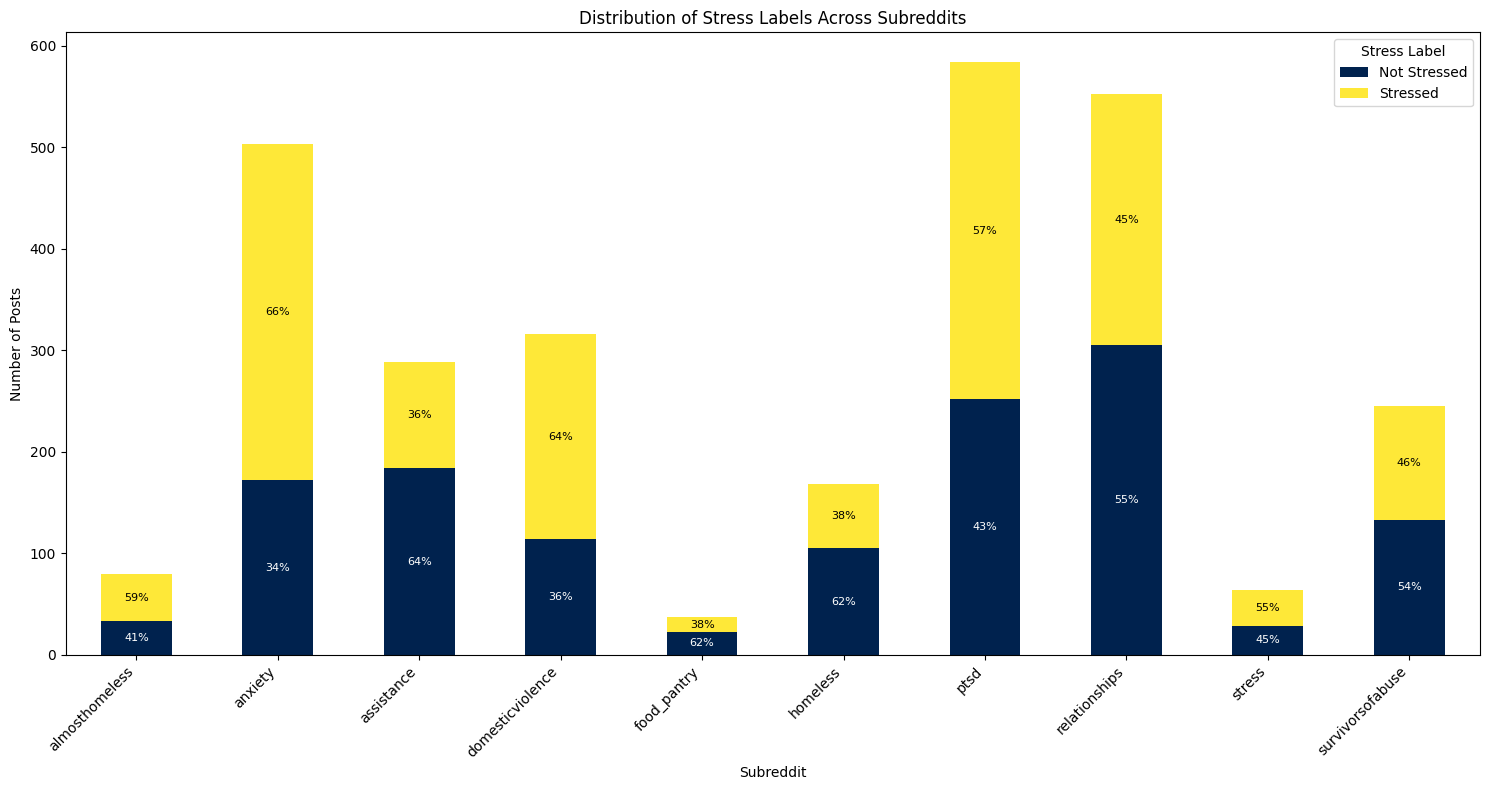

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by subreddit and label, then unstack to get counts for each label per subreddit
subreddit_label_counts = df.groupby(['subreddit', 'label']).size().unstack(fill_value=0)

# Rename columns for better readability in the legend
subreddit_label_counts = subreddit_label_counts.rename(columns={0: 'Not Stressed', 1: 'Stressed'})

# Plotting the stacked bar chart
plt.figure(figsize=(15, 8))
ax = subreddit_label_counts.plot(kind='bar', stacked=True, figsize=(15, 8), colormap='cividis') # Changed colormap to 'cividis'
plt.title('Distribution of Stress Labels Across Subreddits')
plt.xlabel('Subreddit')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45, ha='right') # Tilt and align labels
plt.legend(title='Stress Label')

# Add percentages on top of each segment
for i, subreddit in enumerate(subreddit_label_counts.index):
    total = subreddit_label_counts.loc[subreddit].sum()
    not_stressed_val = subreddit_label_counts.loc[subreddit, 'Not Stressed']
    stressed_val = subreddit_label_counts.loc[subreddit, 'Stressed']

    # Calculate percentages
    not_stressed_pct = (not_stressed_val / total) * 100 if total > 0 else 0
    stressed_pct = (stressed_val / total) * 100 if total > 0 else 0

    # Position for 'Not Stressed' text
    if not_stressed_val > 0:
        ax.text(i, not_stressed_val / 2, f'{not_stressed_pct:.0f}%',
                ha='center', va='center', color='white', fontsize=8)

    # Position for 'Stressed' text
    if stressed_val > 0:
        ax.text(i, not_stressed_val + (stressed_val / 2), f'{stressed_pct:.0f}%',
                ha='center', va='center', color='black', fontsize=8)

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

This stacked bar chart shows the distribution of 'stressed' (1) and 'not stressed' (0) labels for each subreddit, allowing us to see which subreddits have a higher proportion of stressed posts.

From the graph above, there are 5 subreddits ('almosthomeless', 'anxiety', 'domesticviolence', 'ptsd', and 'stress') which have a higher proportion of posts labelled stressed compared to posts labelled not stressed.

## Check distribution of word count across labels

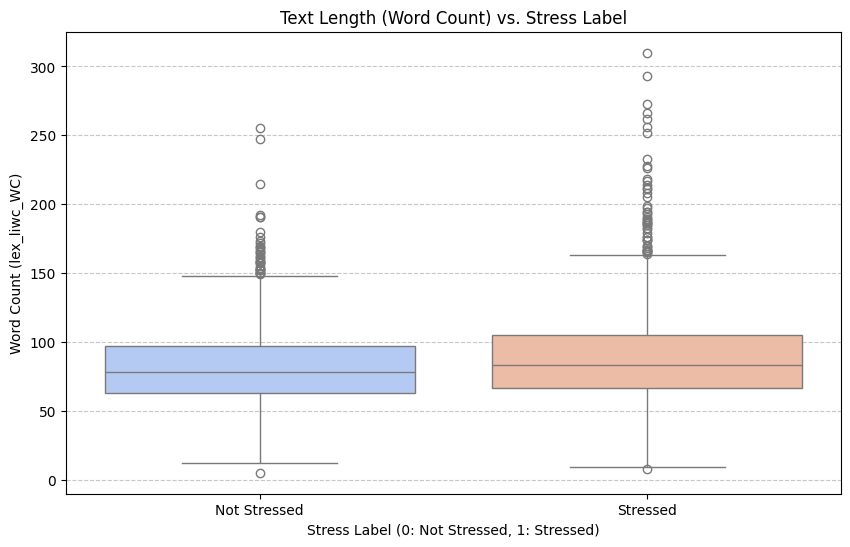

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='lex_liwc_WC', data=df, palette='coolwarm', hue='label', legend=False)
plt.title('Text Length (Word Count) vs. Stress Label')
plt.xlabel('Stress Label (0: Not Stressed, 1: Stressed)')
plt.ylabel('Word Count (lex_liwc_WC)')
plt.xticks(ticks=[0, 1], labels=['Not Stressed', 'Stressed'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

These are boxplots of the length of the post by label. Posts labelled 'Stressed' are slightly longer in length, but both lables have outliers that skew towards long post lengths.

## Check if emotions of the posts affect whether it is labelled as 'Stressed'

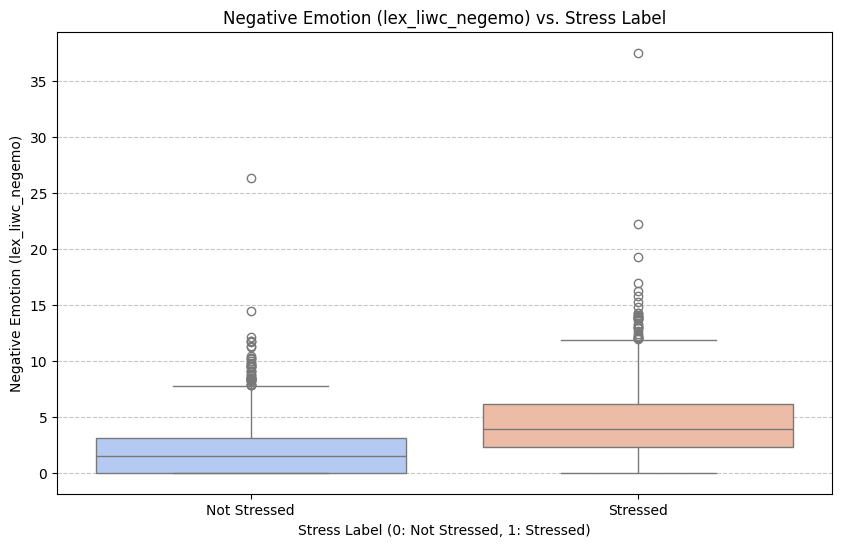

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='lex_liwc_negemo', data=df, palette='coolwarm', hue='label', legend=False)
plt.title('Negative Emotion (lex_liwc_negemo) vs. Stress Label')
plt.xlabel('Stress Label (0: Not Stressed, 1: Stressed)')
plt.ylabel('Negative Emotion (lex_liwc_negemo)')
plt.xticks(ticks=[0, 1], labels=['Not Stressed', 'Stressed'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

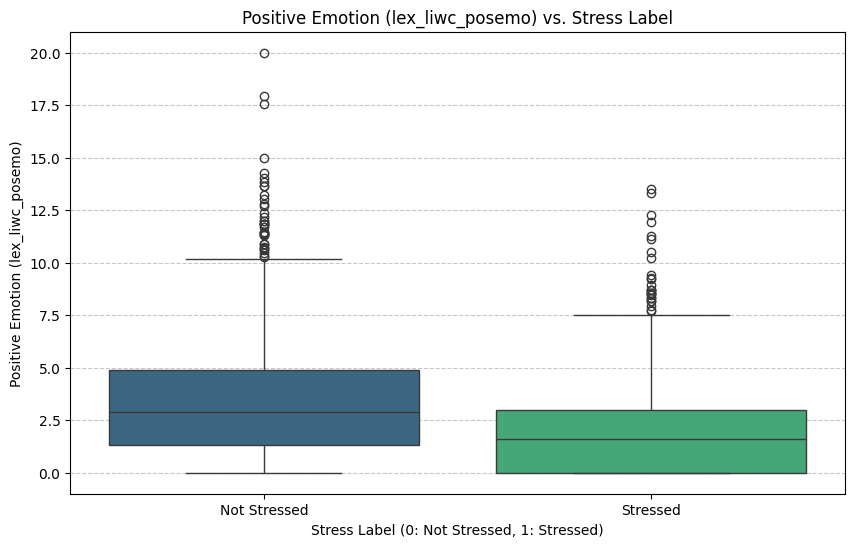

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='lex_liwc_posemo', data=df, palette='viridis', hue='label', legend=False)
plt.title('Positive Emotion (lex_liwc_posemo) vs. Stress Label')
plt.xlabel('Stress Label (0: Not Stressed, 1: Stressed)')
plt.ylabel('Positive Emotion (lex_liwc_posemo)')
plt.xticks(ticks=[0, 1], labels=['Not Stressed', 'Stressed'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In general, the posts which are labelled as 'Not Stressed' have a higher median lex_liwc_posemo, and a lower median for lex_liwc_negemo. The opposite is true for the posts labelled as 'Stress'. This is to be expected as posts which are labelled as 'Stress' will be more likely to contain words that carry negative emotions.

# Feature Selection and Preprocessing

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer

# Define categorical features
categorical_features = ['subreddit']

# Identify numerical feature columns
excluded_columns = ['text', 'label', 'subreddit', 'sentence_range', 'id', 'post_id', 'confidence']
numerical_features = [col for col in df.columns if col not in excluded_columns]

# Create the feature DataFrame X, including 'text', 'subreddit', and numerical features
#X = df_drop[['text'] + categorical_features + numerical_features]

# Create the target Series y
#y = df_drop['label']

X_train = df[['text'] + categorical_features + numerical_features]
y_train = df['label']
X_test = df_test[['text'] + categorical_features + numerical_features]
y_test = df_test['label']

print("Libraries imported successfully.")
print("Features (X) and target (y) separated with 'text', 'subreddit', and numerical features included.")

Libraries imported successfully.
Features (X) and target (y) separated with 'text', 'subreddit', and numerical features included.


#Baseline Models

## Majority Class Baseline Model

To establish a baseline, we implement a 'Majority Class' classifier. This model always predicts the most frequent class found in the training data. This helps us understand what performance we would get by simply guessing the most common outcome, and any machine learning model should ideally perform better than this baseline.

In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Identify the majority class in the training data
majority_class = y_train.value_counts().idxmax()
print(f"Majority class in training data: {majority_class}")

# 2. Instantiate DummyClassifier with 'most_frequent' strategy
dummy_classifier = DummyClassifier(strategy='most_frequent', random_state=42)

# 3. Train the dummy classifier
dummy_classifier.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred_baseline = dummy_classifier.predict(X_test)

# 5. Evaluate the baseline model
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline, average='weighted', zero_division=0)
recall_baseline = recall_score(y_test, y_pred_baseline, average='weighted', zero_division=0)
f1_baseline = f1_score(y_test, y_pred_baseline, average='weighted', zero_division=0)

print("\n--- Majority Class Baseline Model Performance ---")
print(f"Accuracy: {accuracy_baseline:.4f}")
print(f"Precision: {precision_baseline:.4f}")
print(f"Recall: {recall_baseline:.4f}")
print(f"F1-Score: {f1_baseline:.4f}")

Majority class in training data: 1

--- Majority Class Baseline Model Performance ---
Accuracy: 0.5161
Precision: 0.2663
Recall: 0.5161
F1-Score: 0.3514


## Logistic Regression with only Text

To establish another baseline, we implement a simple logistic regression using only data from the 'Text' column and without doing any tuning on the parameters.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold, cross_validate # Added cross_validate
import numpy as np # Added numpy

#Create baseline pipeline
baseline_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),   # default settings
    ('clf', LogisticRegression(max_iter=2000, random_state=42))
])

# Cross-fold validation
X_cv = df['text']
y_cv = df['label']

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

# Perform cross-validation
cv_results = cross_validate(baseline_pipeline, X_cv, y_cv, cv=skf, scoring=scoring, n_jobs=-1)
print("--- Baseline Model Cross-Validation Results ---")
for metric_name, scores in cv_results.items():
    if metric_name.startswith('test_'):
        print(f"{metric_name.replace('test_', '').replace('_', ' ').capitalize()}: ")
        print(f"  Mean: {np.mean(scores):.4f}")
        print(f"  Standard Deviation: {np.std(scores):.4f}")

#Fit on training data
baseline_pipeline.fit(X_train['text'], y_train)

#Predict on test data
y_pred_baseline = baseline_pipeline.predict(X_test['text'])

#Evaluate
baseline_f1 = f1_score(y_test, y_pred_baseline)

print("Baseline Test F1:", baseline_f1)

--- Baseline Model Cross-Validation Results ---
Accuracy: 
  Mean: 0.7583
  Standard Deviation: 0.0111
Precision: 
  Mean: 0.7532
  Standard Deviation: 0.0088
Recall: 
  Mean: 0.8017
  Standard Deviation: 0.0212
F1: 
  Mean: 0.7766
  Standard Deviation: 0.0118
Baseline Test F1: 0.7455012853470437


#Exploring Models + Tuning

## Model with LIWC and Bag-of-Words (CountVectorizer)

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer # Changed from TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# -------- 1. Define transformers -------- #

text_transformer = CountVectorizer(
    max_features=10000 # Limiting features for computational efficiency, similar to previous TF-IDF model
)


numerical_transformer = StandardScaler(with_mean=False)

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# -------- 2. Define classifier -------- #

logistic_regression_model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=2000,
    random_state=42
)

# -------- 3. ColumnTransformer -------- #

preprocessor = ColumnTransformer(
    transformers=[
        ('text_vec', text_transformer, 'text'),
        ('cat_ohe', categorical_transformer, categorical_features),
        ('num_scale', numerical_transformer, numerical_features)
    ],
    remainder='drop'
)

# -------- 4. Full pipeline -------- #

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', logistic_regression_model)
])

# -------- 5. Parameter grid -------- #

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 5, 10],
    'classifier__class_weight': [None, 'balanced']
}

# -------- 6. Cross-validation setup -------- #

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

X_train = df[['text'] + categorical_features + numerical_features]
y_train = df['label']
X_test = df_test[['text'] + categorical_features + numerical_features]
y_test = df_test['label']

# -------- 7. Fit on training data -------- #

grid_search.fit(X_train, y_train)

print("Best CV F1:", grid_search.best_score_)
print("Best Params:", grid_search.best_params_)

# -------- 8. Evaluate on test set -------- #

best_model_bow = grid_search.best_estimator_

y_pred_bow = best_model_bow.predict(X_test)

print("Test F1 (BoW):", f1_score(y_test, y_pred_bow))

Best CV F1: 0.7851646313472751
Best Params: {'classifier__C': 0.01, 'classifier__class_weight': None}
Test F1 (BoW): 0.7754569190600522


## Model with LIWC and stop_words

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# -------- 1. Define transformers -------- #

text_transformer = TfidfVectorizer(
    stop_words='english'
)


numerical_transformer = StandardScaler(with_mean=False)

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# -------- 2. Define classifier -------- #

logistic_regression_model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=2000,
    random_state=42
)
#lbfgs

# -------- 3. ColumnTransformer -------- #

preprocessor = ColumnTransformer(
    transformers=[
        ('text_vec', text_transformer, 'text'),
        ('cat_ohe', categorical_transformer, categorical_features),
        ('num_scale', numerical_transformer, numerical_features)
    ],
    remainder='drop'   # IMPORTANT: avoid leakage
)

# -------- 4. Full pipeline -------- #

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', logistic_regression_model)
])

# -------- 5. Parameter grid -------- #

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 5, 10],
    'classifier__class_weight': [None, 'balanced']
}

# -------- 6. Cross-validation setup -------- #

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

X_train = df[['text'] + categorical_features + numerical_features]
y_train = df['label']
X_test = df_test[['text'] + categorical_features + numerical_features]
y_test = df_test['label']

# -------- 7. Fit on training data -------- #

grid_search.fit(X_train, y_train)

print("Best CV F1:", grid_search.best_score_)
print("Best Params:", grid_search.best_params_)

# -------- 8. Evaluate on test set -------- #

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Test F1:", f1_score(y_test, y_pred))

Best CV F1: 0.7807684232412481
Best Params: {'classifier__C': 1, 'classifier__class_weight': None}
Test F1: 0.7728459530026109


##Model with LIWC and bigrams

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# -------- 1. Define transformers -------- #

text_transformer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

#max_features=10000,
    #ngram_range=(1,2),
    #min_df=3,
    #max_df=0.9,
    #stop_words='english'


numerical_transformer = StandardScaler(with_mean=False)

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# -------- 2. Define classifier -------- #

logistic_regression_model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=2000,
    random_state=42
)
#lbfgs

# -------- 3. ColumnTransformer -------- #

preprocessor = ColumnTransformer(
    transformers=[
        ('text_vec', text_transformer, 'text'),
        ('cat_ohe', categorical_transformer, categorical_features),
        ('num_scale', numerical_transformer, numerical_features)
    ],
    remainder='drop'   # IMPORTANT: avoid leakage
)

# -------- 4. Full pipeline -------- #

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', logistic_regression_model)
])

# -------- 5. Parameter grid -------- #

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 5, 10],
    'classifier__class_weight': [None, 'balanced']
}

# -------- 6. Cross-validation setup -------- #

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

X_train = df[['text'] + categorical_features + numerical_features]
y_train = df['label']
X_test = df_test[['text'] + categorical_features + numerical_features]
y_test = df_test['label']

# -------- 7. Fit on training data -------- #

grid_search.fit(X_train, y_train)

print("Best CV F1:", grid_search.best_score_)
print("Best Params:", grid_search.best_params_)

# -------- 8. Evaluate on test set -------- #

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Test F1:", f1_score(y_test, y_pred))

Best CV F1: 0.7834067147542527
Best Params: {'classifier__C': 1, 'classifier__class_weight': None}
Test F1: 0.7700394218134035


##Model with LIWC

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# -------- 1. Define transformers -------- #

text_transformer = TfidfVectorizer(
)


numerical_transformer = StandardScaler(with_mean=False)

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# -------- 2. Define classifier -------- #

logistic_regression_model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=2000,
    random_state=42
)
#lbfgs

# -------- 3. ColumnTransformer -------- #

preprocessor = ColumnTransformer(
    transformers=[
        ('text_vec', text_transformer, 'text'),
        ('cat_ohe', categorical_transformer, categorical_features),
        ('num_scale', numerical_transformer, numerical_features)
    ],
    remainder='drop'   # IMPORTANT: avoid leakage
)

# -------- 4. Full pipeline -------- #

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', logistic_regression_model)
])

# -------- 5. Parameter grid -------- #

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 5, 10],
    'classifier__class_weight': [None, 'balanced']
}

# -------- 6. Cross-validation setup -------- #

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

X_train = df[['text'] + categorical_features + numerical_features]
y_train = df['label']
X_test = df_test[['text'] + categorical_features + numerical_features]
y_test = df_test['label']

# -------- 7. Fit on training data -------- #

grid_search.fit(X_train, y_train)

print("Best CV F1:", grid_search.best_score_)
print("Best Params:", grid_search.best_params_)

# -------- 8. Evaluate on test set -------- #

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Test F1:", f1_score(y_test, y_pred))

Best CV F1: 0.7881767659485661
Best Params: {'classifier__C': 1, 'classifier__class_weight': None}
Test F1: 0.7805519053876478


## Final Model (Model with TF-IDF + LIWC + max_features=10000)

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# -------- 1. Define transformers -------- #

text_transformer = TfidfVectorizer(
    max_features=10000
    #ngram_range=(1,2)
)

#max_features=10000,
    #ngram_range=(1,2),
    #min_df=3,
    #max_df=0.9,
    #stop_words='english'


numerical_transformer = StandardScaler(with_mean=False)

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# -------- 2. Define classifier -------- #

logistic_regression_model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=2000,
    random_state=42
)
#lbfgs

# -------- 3. ColumnTransformer -------- #

preprocessor = ColumnTransformer(
    transformers=[
        ('text_vec', text_transformer, 'text'),
        ('cat_ohe', categorical_transformer, categorical_features),
        ('num_scale', numerical_transformer, numerical_features)
    ],
    remainder='drop'   # IMPORTANT: avoid leakage
)

# -------- 4. Full pipeline -------- #

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', logistic_regression_model)
])

# -------- 5. Parameter grid -------- #

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 5, 10],
    'classifier__class_weight': [None, 'balanced']
}

# -------- 6. Cross-validation setup -------- #

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

X_train = df[['text'] + categorical_features + numerical_features]
y_train = df['label']
X_test = df_test[['text'] + categorical_features + numerical_features]
y_test = df_test['label']

# -------- 7. Fit on training data -------- #

grid_search.fit(X_train, y_train)

print("Best CV F1:", grid_search.best_score_)
print("Best Params:", grid_search.best_params_)

# -------- 8. Evaluate on test set -------- #

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Test F1:", f1_score(y_test, y_pred))

Best CV F1: 0.7876556357480181
Best Params: {'classifier__C': 1, 'classifier__class_weight': None}
Test F1: 0.7821522309711286


## Model Rationale

I chose to use logistic regression as the primary classification model due to its strong performance in high-dimensional sparse text settings and its interpretability. In addition, TF-IDF representations typically produce thousands of features, and linear models such as logistic regression are well-suited for such feature spaces.

I used TF-IDF (Term Frequency-Inverse Document Frequency) for analysing the 'text' column, as it can be used to transform raw text into numerical features that can be used to reflect the relative importance of words within each post. Unlike simple bag-of-words representations, which places more emphasis on the frequency of words in the posts, TF-IDF down-weights common words and emphasises distinctive terms, which might be more useful when we want to analyse stress-related language patterns.

In addition to the data from the 'text' column, I incorporated psycholinguistic features (LIWC) and community-level context (subreddit) in my training models. From the earlier exploratory data analysis, it was found that the emotion of the posts has a correlation with whether the post is labelled 'stressed' or not. This is likely because LIWC captures psychologically meaningful categories such as anxiety, negative emotion, and cognitive processes, which may correlate with stress expression. Subreddit was included to account for contextual differences in how stress is discussed across communities.

Since the goal of this project is not to just do performance prediciton but to do sense-making as well, I also chose logistic regression as it provides direct access to feature coefficients. It allows us to interpret which words, linguistic markers (eg LIWC features), and community contexts (subreddit) most strongly contribute to stress prediction.

However, logistic regression assumes a linear decision boundary in feature space, and this may limit its ability to capture complex nonlinear interactions. More complex models such as deep neural networks or transformer-based models may achieve higher performance, but at the cost of reduced interpretability and increased computational complexity. Given the mental health application, I prioritised choosing a model  with transparency and easier interpretability.

## Model Architecture
The model architecture consists of a preprocessing pipeline combining TF-IDF text vectorisation, one-hot encoding of subreddit features, and scaling of numerical linguistic features, followed by an L2-regularised logistic regression classifier for binary stress prediction.

Firstly, to ensure that the models' performance is not accidentally evaluated on skewed splits, I used 5-fold stratified cross-fold validation on the training set. This ensures stable performance estimation while preserving class proportions across folds. I chose to use 5 folds for cross-fold validation as it allows for a reasonably larger number of splits to be done while being computationally expensive.

Secondly, I used a pipeline to ensure that scaling and standardisation of numerical features and transforming texts are done separately inside each fold, instead of on the full set to prevent data leakage.

Thirdly, I set the penalty = L2 for this logistic regression. Logistic regression with L2 regularisation was selected over L1 due to the high-dimensional and correlated nature of TF-IDF text features. L2 regularisation shrinks coefficients smoothly and distributes weights across correlated lexical features, leading to more stable and generalisable models.

## Hyperparameter Tuning Rationale

I used grid search to find the best parameters for the logisitic regression, namely the strength of the 'C' value, which affects the strength of the regularisation, and for class weight, which determines whether the model should treat all classes equally regardless of its frequency or not.

Based on the results of grid search, the best value for C is 1, which is a relatively small value and means stronger regularisation and less likely for the model to overfit. This is likely becuase there are a lot of features and hence stronger regularisation is needed. The best class weight is also 'None', which is most likely because the classes were already fairly balanced in the first place.

In addition to grid search, I manually tuned some parameters in the text transformer model and compared the models with the different parameters. I wanted to find out whether limiting the max_features to 10000, considering bigrams instead of just unigrams, and adding stopwords affected the F1 score. I did not do grid search for these as it was computationally expensive and was taking a long time to run.

However, in the future, more values for these parameters should be considered. In addition, using randomised search instead of grid search may save some time as well. Unlike grid search, which exhaustively evaluates all combinations of predefined hyperparameter values, randomized search samples from specified parameter distributions. This approach allows exploration of a larger hyperparameter space within a fixed computational budget, often achieving comparable performance at reduced training time.


## Discussion of Models
From comparing the F1 scores of the various models above, the model that had the best F1 score on the test set was the model that included data from the 'text' and 'subreddit' columns, the LIWC features, used TF_IDF, had the max_features parameter in the text transformer set to 10000, and had no stopwords.

Including LIWC features likely helped in training the models because it contained additional information that might not be captured in text alone, like the tone of the post, of whether the post seemed to be focused on the past or not. TF-IDF was also likely better than just using bag-of-words as it considers the relative importance of the words in each post, instead of the just the frequency. Setting the max_features to 10000 instead of the default 'None' may have also decreased noise and led to better performance of the model. I decided to include the 'subreddit' column as I thought that it might contextualise what kind of stress (eg good vs bad stress) might be present in the post, but it may have introduced bias.

Across all the models above, the F1 score was generally similar. This could be because as we can see from the best parameters from grid search, the best parameters were already the default values.

It was surprising that adding bigrams and stopwords did not increase the F1 score, and in fact, resulted in a lower F1 score. However, there could be some reasons why this happened.

I considered bigrams as pairs of words together might carry more information than just a single word alone. For example, 'can't sleep' might be better indicator of stress than just 'sleep'. However, when considering bigrams in the model, we doubled the feature space and may have introduced more noise, resulting in a lower performance for the model even if more useful information was added.

Additionally, while removing stopwords often helps in topic or sentiment classification, stopwords can actually be important in mental health detection. Stopwords often contain pronouns and negation (eg 'not', 'no'), and these may be useful in predicting stress. Prnouns like 'I' and 'me' may indicate self-focus and negations may indicate feelings of self-doubt (eg 'I cannot', 'I don't know what to do') or negative feelings, which also are useful in predicting stress. Hence, when removing stopwords, we may have removed clinically informative language.



# Analysis 1: Top features contributing to whether the post is labelled stressed or not

In [27]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

coefficients = best_model.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

coef_df = coef_df.sort_values(by='coefficient', ascending=False)
top_positive = coef_df.head(20)
top_negative = coef_df.tail(20).sort_values(by='coefficient', ascending=True) # Sort in ascending order so invert_yaxis puts most negative at top

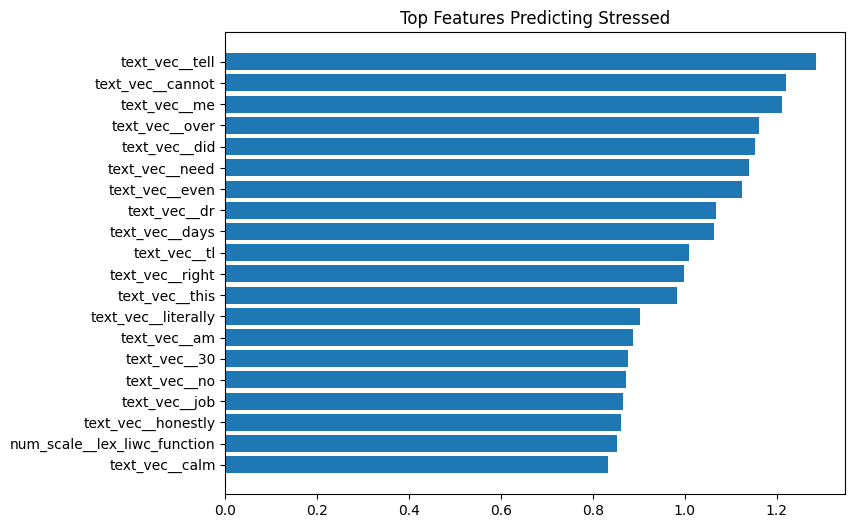

In [28]:
plt.figure(figsize=(8,6))
plt.barh(top_positive['feature'], top_positive['coefficient'])
plt.gca().invert_yaxis()
plt.title("Top Features Predicting Stressed")
plt.show()

The top features precdiciting 'Stressed' have a lot of self-focus and personal expression. For example, 'me', 'am', 'did' and 'honestly' are such words. This suggests that stressed posts tends to be self-focused and emotionally expressive. This makes sense as higher first-person pronoun usage is found to be correlated with stress, and emotional disclosure can often increase self-referential languauge.

Additionally, the top features like 'cannot', 'no', 'need' and 'over' indicate lack of control or feeling overwhelmed. These words may reflect the poster's feelings of urgency and inability to do something, which is consistent with language relating to stress.

Lastly, there are also features relating to life stressors, like 'job', 'dr' and '30'. These may reflect work stress, stress related to health, and stress related to aging.

Interestingly, the word 'calm' appears in the top features, even though it does not carry a negative connotation. It may have appeared in phrases like 'not calm' or 'I can't calm down'. Unigrams (used in my model) cannot capture negation context properly, which may have been what happened in this case.

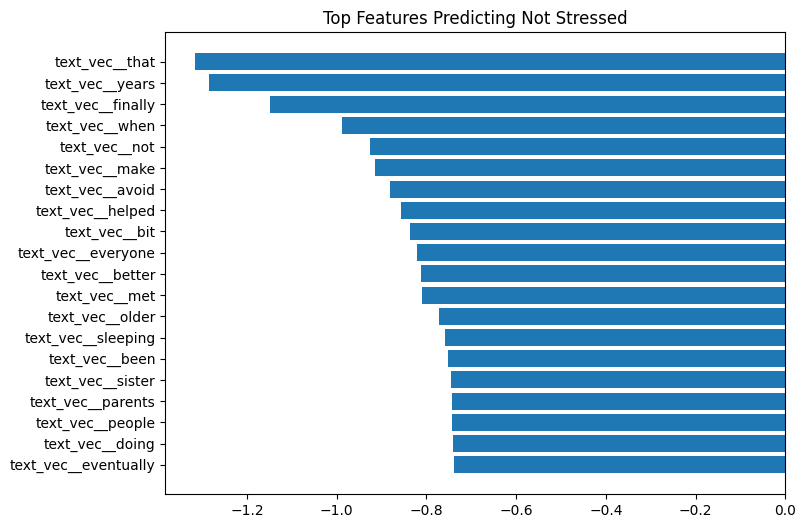

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.barh(top_negative['feature'], top_negative['coefficient'])
plt.gca().invert_yaxis()
plt.title("Top Features Predicting Not Stressed")
plt.show()

The top predictors that do not contribute to the post being labelled as 'stressed' have references to social or family connections, like 'parents', 'people', 'sister' and 'everyone'. These posts may have been talking about other people rather than their ownself, and be more informational rather than self-focused. This aligns with our insight above that stressed posts are more self-focused in nature. Additionally, it may be that these words show that the poster have a strong support system around them, which may lead to a lower indicator of stress.

There are also words relating to resolution and imporvement, like 'better', 'helped', 'finally' and 'eventually'. These words may suggest feelings of recovery and relief, which are feelings that are very different or even opposite of stress.

It is surprising that 'not', a word indicating negation, appears here. However, as mentioned above, since my model only considered unigrams, 'not' could have been used alongside other words to mean something positive instead. This suggests that isolated negation may not be a strong stress marker without contextual information.

In conclusion, stressed posts are often self-focused and express feelings of urgency and inability, while non-stressed posts are more informational, are less self-focused, and contain language relating to recovery or relief.

# Analysis 2: Comparing F1 Scores across Subreddits

In [20]:
df_test['prediction'] = best_model.predict(X_test)

subreddit_scores = []

for subreddit in df_test['subreddit'].unique():
    subset = df_test[df_test['subreddit'] == subreddit]
    f1 = f1_score(subset['label'], subset['prediction'])
    subreddit_scores.append((subreddit, f1))

subreddit_scores = pd.DataFrame(subreddit_scores, columns=['subreddit', 'f1'])
subreddit_scores = subreddit_scores.sort_values(by='f1', ascending=False) # Assign sorted DataFrame back to subreddit_scores
subreddit_scores

,subreddit,f1
9,food_pantry,1.000000
6,domesticviolence,0.877551
8,stress,0.857143
1,anxiety,0.848168
2,ptsd,0.812121
5,almosthomeless,0.800000
3,assistance,0.761905
7,survivorsofabuse,0.676923
4,homeless,0.648649
0,relationships,0.625000


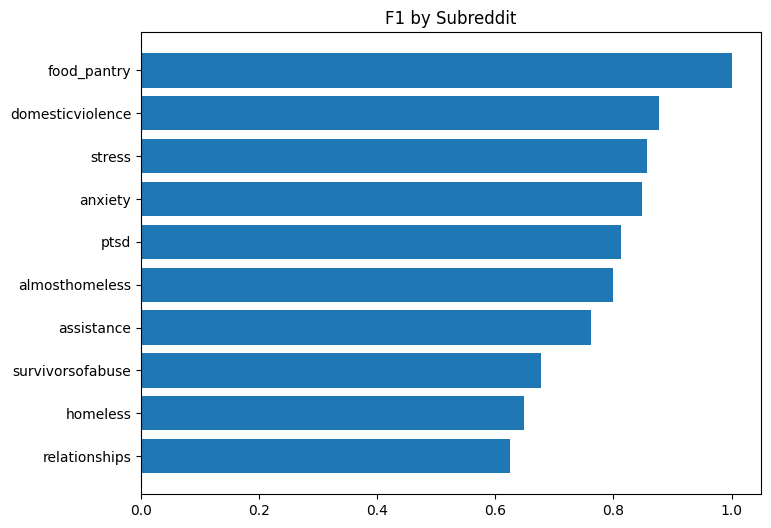

In [21]:
plt.figure(figsize=(8,6))
# Sort in ascending order for plotting from bottom to top to get descending visual order
plot_data = subreddit_scores.sort_values(by='f1', ascending=True)
plt.barh(plot_data['subreddit'], plot_data['f1'])
plt.title("F1 by Subreddit")
plt.show()

The subreddits with high F1 scores of above 0.8 are 'food_pantry', 'domesticviolence', 'stress', 'anxiety', 'ptsd' and 'almosthomeless'.

These may be because these subreddits have thematic homogeneity, especially for subreddits like 'stress', 'anxiety', 'ptsd', and 'domesticviolence'. These means that the posts there are more likely to be emotionally intense, directly addressing mental distress and are more linguistically aligned with stress vocabulary.

On the other hand, the subreddit 'relationships' has the lowest F1 score. This may be because there may be mixed content in the subreddit. Some posts may be stressed, but some may be seeking advice in a calm way, and some might be neutral. Words like 'over', 'need' and 'tell', which appeared in our top features in predicting whether a post is stressed or not, may also be used in stressed and non-stressed contexts, making it difficult for the model to accurately identify whether a post is stressed or not.

We should also acknowledge that the subreddit 'food_pantry' has an F1-score of 1. It is highly unlikely that the model is perfect at classifying posts in this subreddit. Rather, it is likely that it has a perfect F1 score because this subreddit has a very small sample size and a skewed distribution. From the earlier EDA section, this subreddit has less than 100 posts and 62% of posts are classified as stressed. This highlights the instability of the model in settings where there are very small sample sizes.

In conclusion, subreddits centred explicitly around mental health exhibit more consistent linguistic markers of distress, making them easier for the model to classify accurately. While in cases where emotional tone is ambiguous and stress is context-dependent rather than explicit, the model may struggle.


# Analysis 3: Cases where Model Confidently Predicts Wrong

In [22]:
# Get probability estimates for each class
# The output will be an array where each row is a sample,
# and columns are probabilities for class 0 (Not Stressed) and class 1 (Stressed).
probabilities = best_model.predict_proba(X_test)

# Display the first 5 probability predictions
print("First 5 prediction probabilities (Class 0, Class 1):")
display(probabilities[:5])

# To get the confidence for the predicted class (Class 1 in this case, for 'Stressed')
# you can take the probability of the predicted class.

# Get the probabilities for the positive class (Class 1)
positive_class_probabilities = probabilities[:, 1]

print("\nFirst 5 probabilities for the 'Stressed' class (Class 1):")
display(positive_class_probabilities[:3])

# You can also add these probabilities to your df_test DataFrame if needed
df_test['prediction_proba'] = positive_class_probabilities
print("\nDataFrame with prediction probabilities added:")
display(df_test.head())

First 5 prediction probabilities (Class 0, Class 1):


array([[0.91729282, 0.08270718],
       [0.81673052, 0.18326948],
       [0.54262694, 0.45737306],
       [0.22589038, 0.77410962],
       [0.37214232, 0.62785768]])


First 5 probabilities for the 'Stressed' class (Class 1):


array([0.08270718, 0.18326948, 0.45737306])


DataFrame with prediction probabilities added:


,id,subreddit,post_id,sentence_range,text,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment,prediction,prediction_proba
0,896,relationships,7nu7as,"[50, 55]","Its like that, if you want or not.“ ME: I have...",0,0.8,1.514981e+09,22,-1.238793,...,1.0,1.65864,1.32245,1.80264,0.63,62,-0.148707,0.000000,0,0.082707
1,19059,anxiety,680i6d,"(5, 10)",I man the front desk and my title is HR Custom...,0,1.0,1.493348e+09,5,7.684583,...,1.0,1.69133,1.69180,1.97249,1.00,2,7.398222,-0.065909,0,0.183269
2,7977,ptsd,8eeu1t,"(5, 10)",We'd be saving so much money with this new hou...,1,1.0,1.524517e+09,10,2.360408,...,1.0,1.70974,1.52985,1.86108,1.00,8,3.149288,-0.036818,0,0.457373
3,1214,ptsd,8d28vu,"[2, 7]","My ex used to shoot back with ""Do you want me ...",1,0.5,1.524018e+09,5,5.997000,...,1.0,1.72615,1.52000,1.84909,1.00,7,6.606000,-0.066667,1,0.774110
4,1965,relationships,7r1e85,"[23, 28]",I haven’t said anything to him yet because I’m...,0,0.8,1.516200e+09,138,4.649418,...,1.0,1.75642,1.43582,1.91725,0.84,70,4.801869,0.141667,1,0.627858


## Cases of High-Confidence Misclassifications

In [23]:
# Filter for misclassified cases
misclassified_cases = df_test[df_test['prediction'] != df_test['label']].copy()

# Sort misclassified cases by prediction probability in descending order
# We're interested in the probability of the *predicted* class, which is stored in 'prediction_proba'
# If the model predicted 0 but the true label was 1, prediction_proba would be low.
# If the model predicted 1 but the true label was 0, prediction_proba would be high.
# So, for high confidence *wrong* predictions, we look at high 'prediction_proba' when label=0 (false positive)
# or low 'prediction_proba' when label=1 (false negative with high confidence in class 0).
# However, 'prediction_proba' is explicitly for class 1. So, high confidence wrong prediction implies:
# 1. model predicted 1 (high proba for 1) but true label was 0.
# 2. model predicted 0 (low proba for 1) but true label was 1.

# Let's consider cases where the model predicted 1 with high confidence, but it was actually 0 (False Positives)
# Or where the model predicted 0 with high confidence (i.e., low proba for 1), but it was actually 1 (False Negatives)

# For False Positives (predicted 1, actual 0), we want high 'prediction_proba'
false_positives = misclassified_cases[(misclassified_cases['prediction'] == 1) & (misclassified_cases['label'] == 0)]
false_positives_high_conf = false_positives.sort_values(by='prediction_proba', ascending=False)

# For False Negatives (predicted 0, actual 1), we want low 'prediction_proba' (meaning high confidence in class 0)
false_negatives = misclassified_cases[(misclassified_cases['prediction'] == 0) & (misclassified_cases['label'] == 1)]
false_negatives_high_conf = false_negatives.sort_values(by='prediction_proba', ascending=True)


## Top 2 False Positives

In [24]:
import pandas as pd

pd.set_option('display.max_colwidth', None)

print("Full text for Top 2 False Positives (Predicted 'Stressed' with high confidence, but actual was 'Not Stressed'):")
display(false_positives_high_conf.head(2)['text'])

pd.reset_option('display.max_colwidth')

Full text for Top 2 False Positives (Predicted 'Stressed' with high confidence, but actual was 'Not Stressed'):


,text
540,"What are you thankful for? For me: Today I'm feeling thankful for being alive. I'm very grateful for my family, our health, our safety, my jobs, my home. I have pain in my foot/leg from an injury I had surgery, as painful as it can be it has also made me grateful for being able to walk."
633,"But it took me months afterward to end it. I remember him screaming at me, calling me stupid, calling me a moody bitch when I got frustrated at him for screaming and insulting me, threatening to break up with me, holding his “love” for me over my head when I wasn’t doing things his way, getting drunk and high and cheating on me and then coercing me into helping him fake a piss test, and on and on and on.... And the whole time I knew he was being an abusive asshole and I *still stayed. * I had absolutely no reason not to leave him, and it was 100% in my power to end things between us. But I didn’t."


These posts are wrongly labelled as stressed when they are not stressed. From the posts above, there are a lot of language that relate to negativity and self-focus, which may lead to the model identifying these posts as stressed when it is not.

Take the first post, which is clearly a post expressing gratitude. However, there are words and phrases like 'pain', 'grateful to walk' and 'injury'. The model may have associated medical issues and and survival language with stress-related subreddits like 'ptsd'. Even though the tone is positive, the lexical features overlapped with distressed posts.

The second post also contains words like 'screaming', 'stupid', 'coercing' and 'abusive' which are words relating to violence and abuse. Similarly, the model may have associated these words with posts that are labelled as 'stress'. This post may have been classified as 'not stressed' in the test data despite the content relating to abuse, because the poster is talking about it in the past, and they are not stressed now. In addition, the poster said 'it was 100% in my power to end things between us. But I didn't', indicating they felt like they had control over their relationship. These subtleties may not have been picked up the model, leading to a wrong classification.



In [25]:
pd.set_option('display.max_colwidth', None)
print("\nFull text for Top 2 False Negatives (Predicted 'Not Stressed' with high confidence, but actual was 'Stressed'):")
display(false_negatives_high_conf.head(2)['text'])
pd.reset_option('display.max_colwidth')


Full text for Top 2 False Negatives (Predicted 'Not Stressed' with high confidence, but actual was 'Stressed'):


,text
175,"We met about 2.5 years ago, both somewhat fresh off our respective divorces. I felt we had a real connection, we fell for each other hard, dated (eventually lived together) for a little less than a year before she got pregnant. We were both really happy as we had both talked about wanting children - at the time we got pregnant we were ""not NOT trying,"" we had definitely had many conversations and were both on board and happy to have a child together. We felt we had met our true love in each other. Things have been rough since the birth of our son."
181,"For instance, there was a show on netflix that I thought would be fun to watch together, but she said she couldn't because she used to watch it with her ex and it reminds her of him. Like, are you even over him? She constantly compares me to her ex's in subtle (maybe not subtle) ways, like ""[ex] used to do this thing you do, and you know how I feel about that."" I'm not your ex, I don't think it's fair of you to compare me to him like that all the time. She says she's ""not used to being single,"" it kind of makes me feel like she's using me to get reassurance and validation."


These posts above are wrongly labelled as not stressed when they are stressed. This may be because the language used in these posts are not very negative or violent.

In the first post, there are words like 'connection', 'happy' and 'love'. These words carry a positive sentiment and there are no other intense emotional words in the post. The only part that tells us that the poster is stressed is the last sentence 'Things have been rough since the birth of our son.' The model likely relies heavily on explicit distress words and strong negative sentiment, and hence classified this as not stressed.

For the second post, there are words like 'reassurance' and 'validation' which are also positive words. Even though the tone conveys jealousy and feelings of being compared to, there are no extreme words like 'jealous' or 'anger'. The post was narrated in a structured manner. The model was unable to classify this correctly because it likely depends on more intense and extreme words relating to stress when being trained to identify whether a post is stressed or not.

In conclusion, the model confidently predicts a class as stressed or not stressed wrongly when the post has a lot of extreme words relating to stress or negative emotions, or the post contains words with a positive sentiment, respectively. This suggests that the model is good at detecting explicit distress and keywords relating to stress or abuse. However, it struggles more with subtle stress.

# Model for Deployment and Uses

### Uses

In Singapore, mental health is a top concern. However, many individuals may hesitate to talk about it or seek formal support due to concerns about stigma, employability, or being perceived as “weak.”

However, this stress-detection model can be used to observe the general anxiety levels of Singaporeans by using it on online forums similar to Reddit. It can be used on Singapore-specific forums like Singapore-specific university confession pages and telegram groups, or even in support channels. If the model detects a post as 'stressed', these posts could be flagged and an automated message could be sent to the user directing them to counselling services or self-help resources to reduce stress. There could also be more classes assigned by the model, like 'suicidal', which are posts that indicate that a user is at very high risk of suicide. This system could then alert a human to directly intervene in these cases.

The model can also be used by specific institutions so that they can offer targeted support for those feeling stressed. For example, universities can measure the number of posts that are labelled as 'stress' on university forums over time. If it is found that the number of 'stressed' posts increase during examination season, they might be able to offer more support through offering materials related to lowering exam stress or opening up more slots for counselling sessions.


### Limitations
From the analyses above, the model heavily equates stress with explicit distress vocabulary. However, in Singapore, where mental health is not as openly talked about, people may express stress in a more self-restraint or subtle way, and avoid dramatic language. Therefore, the model may miss out on detecting stress that is expressed in a more subtle way, or if the post is expressing stress in a sarcastic way (eg 'My day is going wonderful!' if the poster has a terrible day.)

This might mean failing to identify someone at-risk, which can be costly in mental health contexts.

At the same time, the model may identify someone as at risk of stress when they are actually not, which may lead to distrust in the model and desensitise responders to threats when there are repeated false positives.

In addition, the model is trained on English posts. But in Singapore, it is common for people to speak in 'Singlish', which contains a mix of English, Mandarin, Malay, and other languages. The model will likely underperform on localised lingustic forums.

### Ethical Concerns
Deploying the models on public forums in Singapore may also raise ethical concerns. Singaporeans may not be aware that what they are writing online is being used for analysis, and even if they are aware, they may feel that it is too intrusive. Some may just want to vent online if they are feeling stressed, and knowing that their words will be anlaysed may make them more self-conscious about what they put online.

In addition, we must ensure that we do not rely on the model too much. Therefore, we must ensure that the model must never replace clinical assessment, only assist human moderators, and be transparent about any uncertainties of the model. This model should be deployed only as a decision-support tool rather than an automated diagnostic system.


### AI Disclaimer
I used Gemini and ChatGPT to outline drafts and to help with creating the code for the models. I am responsible for the content and quality of the submitted work.